# White Mountain National Forest Pole of Inaccessabilty

One way to do this is to do a Voronoi tesselation of points sampled along the roads, as those are the points you want to avoid, and then use the Voronoi vertices as the points to check for maximum distance from any road. That's pretty cool in terms of computational efficiency, but I want to get a heatmap of the WMNF, colored by how inaccessable it is. So step one is to get the points that are roads, and so are the most accessable points. 

We get those from OpenStreetMap, using a modification of the query from https://notes.secretsauce.net/notes/2015/05/06_poles-of-inaccessibility-in-the-san-gabriel-mountains.html

However, that needs a bounding box. The WMNF is actually not even simply connected, nor convex, so we can get the perimeter of it by querying the Nominatim API with an open-format query and ask for JSON output. 

In [ ]:
import json
import pickle
import numpy as np
from geographiclib.geodesic import Geodesic
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Point, shape

# Process _all_ The Data!

The get_data notebook gets a lot of data and store it in two files, wmnf_boundary.json and wmnf_roads.json. I'm just going to call those the boundary and the roads. 

The boundary has a bunch of keys in it, but the main one is 'geojason', which is a MultiPolygon. That means it's a list of Polygons. Each Polygon in the first rank is the exterior perimeter of a Polygon, and each list within that polygon is holes in it. 

The main thing we care about for that is that a point is "in" a region if it's inside the first-rank Polygon, and not inside any of the holes in that Polygon. 

The roads file has the key 'elements', which has two types in it (as dicts). There are 'nodes' which have IDs and geographic locations, and 'ways', which have a list of nodes that I assume creates a path when traversed in order. 

# Voronoi of the Road Points

This is not actually an accurate way to do this, because of a couple of reasons, at least one each of philosophical and technical. The technical reason is that the Voronoi diagram of the road points only deals with points on approximations of roads, and so there may be long stretches of road that technically get closer to a given point, but are represented by only two Voronoi centers because the road was approximated as perfectly straight. This seems unlikely in the Whites, though. 

The philosophical reason is that the WMNF has highly variable terrain and trail quality. The spot that is farthest from any road or trail may not be the hardest spot to get to, as measured by experienced difficulty of approach. It's just the spot that's furthest away. For things like the global pole of inaccessability (Point Nemo), ocean is pretty much ocean. Weather makes it better or worse, but it's on average flat and at sea level, without big obstacles. 

My first plan was to make a point set of the road points that fall inside of the WMNF boundary, and another point set of the boundary itself and do the analysis on that, but since I can just do the Voronoi of all the roads in the entire bounding box, and then get the vertices of _that_. One of those verticies is the pole of inaccessability, in the sense that it's the point furthest from all the roads that are closer to it than any other point. Find the vertex that's in the WMNF and at the greatest distance from its centroid, and end up in a Ty Gagne story. 

In [ ]:
with open("wmnf_roads.json", 'r') as infile:
    wmnf_roads = json.load(infile)

Making Voronoi diagram of 748623 points


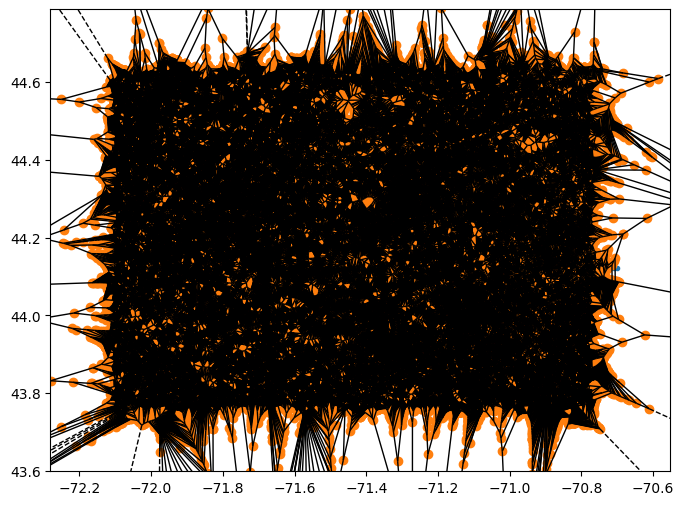

In [ ]:
# Convert all the road points to just numpy points, and then do the Voronoi of that. 
combined_points = []
# Get the roads inside this polygon
for element in wmnf_roads["elements"]:
    if element["type"] == "node":
        combined_points.append([element["lon"], element["lat"]])

# Make a Voronoi diagram of that
all_pts = np.array(combined_points)
print(f"Making Voronoi diagram of {len(combined_points)} points")
vor = Voronoi(all_pts)
with open(f"all_roads_vor.pkl", "wb") as outfile:
    pickle.dump(vor, outfile)
fig = voronoi_plot_2d(vor)
fig.set_size_inches(8,6)
plt.savefig(f"all_roads_plot.png")

Next up, find the vertex of the Voronoi diagram that is farthest from any road point. We have a Voronoi object, which has a bunch of properties (as was the fashion at the time). Those peroperties include:
- `vertices` - The corners of each Voronoi region
- `points` - The original points, in this case on roads
- `regions` - lists of vertex indices for regions
- `point_region` - index of the region for each point (this one is key)

Some of the regions have a vertex index of -1, which is inifinity (off the edge of the space), so that has to be handled. I think that a lot of those will be taken out by checking if the point for the region is inside the WMNF, but it doesn't hurt to be safe. Well, it hurts runtime, but only a little. 

So the overall plan is, for each point, get its `point_region`, and for each vertex in that region, get the distance to the point, and record the _minimum_ distance. In other words, for the region, which is all points closer to the road point than any other point, keep the closest one. The vertex that has the _largest minimum distance_ to a point is pole of inaccessability.

The whole "largest minimum distance" (LMD) thing is also known as the radius of the largest empty circle. Each vertex's minimum distance is stored in a global hash because a vertex's LMD in region A may be larger than the LMD in region B for a vertex between regions A and B, and we want the global LMD. 

In [ ]:
with open("wmnf_boundary.json", 'r') as infile:
    wmnf_data = json.load(infile)
    mp_border = shape(wmnf_data[0]["geojson"])

In [ ]:
with open("all_roads_vor.pkl", 'rb') as infile:
    vor = pickle.load(infile)
    
    # Storage for the minimum distances from vertices to points
    vertex_lmds = {}

    for pt_idx, region_idx in enumerate(vor.point_region):
        point = vor.points[pt_idx]
        region_pt_idxs = vor.regions[region_idx]
        # Don't care about regions with a vertex at inifinity (edge areas)
        if any(vert_idx == -1 for vert_idx in region_pt_idxs):
            continue
        # Convert from indices to actual points
        vtx_pts = [vor.vertices[idx] for idx in region_pt_idxs]
        # Get distance from each vertex to the center point
        for vtx in vtx_pts:
            # Check if it's in the WMNF, we don't care about vertices that are not
            p = Point(vtx)
            if(p.within(mp_border)):            
                # Inverse wants (lat0, lon0, lat1, lon1), but our points are lon, lat
                # This distance is in meters
                dm = Geodesic.WGS84.Inverse(point[1], point[0], vtx[1], vtx[0])['s12']
                storage_key = (vtx[1].item(), vtx[0].item())
                if storage_key in vertex_lmds.keys():
                    if vertex_lmds[storage_key] > dm:
                        # Keep the minnimum distance (min empty circle radius) for this vertex
                        vertex_lmds[storage_key] = dm
                else:
                    vertex_lmds[storage_key] = dm

In [ ]:
lmd = float('-inf')
pole = None
for pt, d in vertex_lmds.items():
    if d > lmd:
        lmd = d
        pole = pt
print(f"{pole} is {d} from the nearest trail or road")

(44.559893582993, -71.44843552532974) is 101.3690250932968 from the nearest trail or road
